# Stakes Group Analysis

Group-level Stakes review notebook. Load one or more cohorts, prepare the shared filtered view once, then plot a group summary + JND figure and the sound-ramp comparison using SEM across animals.

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Cohorts

`DATASET_SELECTIONS` is the safest option when you want an explicit cohort subset. Set it to `None` to use all cohorts listed in `COHORTS`.

In [2]:
COHORTS = ["cohort2"]

# Explicit selections can list any subset of Stakes cohorts, e.g.:
# DATASET_SELECTIONS = ["cohort2"]
DATASET_SELECTIONS = None

## 3. Group Filter Settings

In [3]:
TRAINING_LEVEL = None
TRAINING_LEVEL_MIN = 6
TRAINING_LEVEL_MAX = None
ABL_FILTER = 20
SOUND_RAMP_FILTER = None
SOUND_RAMP_EXCLUDE = [0.005, 0.02]

## 4. Load Once, Prepare Once

In [4]:
from Pipeline.daily_plots import (
    load_stakes_group_data,
    prepare_stakes_group_data,
)
import Pipeline.biased_blocks as bb
import pandas as pd


def filter_group_review_rows(df):
    out = df.copy()
    session_type = pd.to_numeric(out.get("session_type"), errors="coerce")
    short_duration = pd.to_numeric(out.get("short_duration"), errors="coerce")

    keep_non_23 = ~session_type.eq(23)
    keep_23 = pd.Series(False, index=out.index, dtype=bool)
    type23 = out[session_type.eq(23)].copy()
    if not type23.empty:
        labeled_23 = bb.add_biased_block_condition(
            type23,
            biased_session_types=(23,),
            unbiased_rt_session_types=(),
            short_duration_value=None,
        )
        keep_23 = out.index.isin(labeled_23.index[labeled_23["block_condition"].eq("unbiased")])
    keep_23_like_rt_unbiased = keep_23 & short_duration.eq(0)
    return out[keep_non_23 | keep_23_like_rt_unbiased].copy()


df_raw, loaded_cohorts = load_stakes_group_data(
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
)
df_group_input = filter_group_review_rows(df_raw)
group_prepared = prepare_stakes_group_data(
    df_group_input,
    training_level=TRAINING_LEVEL,
    training_level_min=TRAINING_LEVEL_MIN,
    training_level_max=TRAINING_LEVEL_MAX,
    abl_filter=ABL_FILTER,
    sound_ramp_filter=SOUND_RAMP_FILTER,
    sound_ramp_exclude=SOUND_RAMP_EXCLUDE,
)

print("Loaded cohorts:", loaded_cohorts)
print(f"Training filters: level={TRAINING_LEVEL}, min={TRAINING_LEVEL_MIN}, max={TRAINING_LEVEL_MAX}, ABL={ABL_FILTER}")
print(f"Ramp filters: keep={SOUND_RAMP_FILTER}, exclude={SOUND_RAMP_EXCLUDE}")
print(f"Raw rows: {len(df_raw)}")
print(f"Rows after session-23 unbiased-block RT filter: {len(df_group_input)}")
print(f"Prepared rows: {len(group_prepared['df'])}")
print(f"Animals: {group_prepared['info']['n_animals']}")
print(f"Sessions: {group_prepared['info']['n_sessions']}")
group_prepared['info']

    ABL       JND
0  20.0  2.647979
    ABL       JND
0  20.0  2.775587
    ABL       JND
0  20.0  2.455005
    ABL       JND
0  20.0  2.751959
    ABL     JND
0  20.0  2.6369
    ABL       JND
0  20.0  1.653095
    ABL       JND
0  20.0  2.354053
    ABL       JND
0  20.0  3.112679
    ABL       JND
0  20.0  2.305867
    ABL       JND
0  20.0  2.481798
    ABL       JND
0  20.0  2.364904
    ABL      JND
0  20.0  2.17124
    ABL      JND
0  20.0  1.83145
    ABL       JND
0  20.0  2.428652
    ABL       JND
0  20.0  2.055808
    ABL       JND
0  20.0  1.513567
    ABL       JND
0  20.0  2.488102
    ABL       JND
0  20.0  3.136411
    ABL      JND
0  20.0  2.65538
    ABL       JND
0  20.0  2.253376
    ABL       JND
0  20.0  2.219172
    ABL       JND
0  20.0  1.395532
    ABL       JND
0  20.0  1.716132
    ABL       JND
0  20.0  3.048873
    ABL       JND
0  20.0  2.096136
    ABL       JND
0  20.0  2.625999
    ABL       JND
0  20.0  2.063504
    ABL       JND
0  20.0  2.037307
  

{'line': ['Stakes'],
 'cohorts': ['cohort2'],
 'n_animals': 9,
 'animals': ['JCS0014',
  'JCS0015',
  'JCS0016',
  'JCS0017',
  'JCS0018',
  'JCS0019',
  'JCS0020',
  'JCS0021',
  'JCS0022'],
 'n_sessions': 315,
 'n_trials': 144883}

## 5. Figure 1: Group Summary + JND

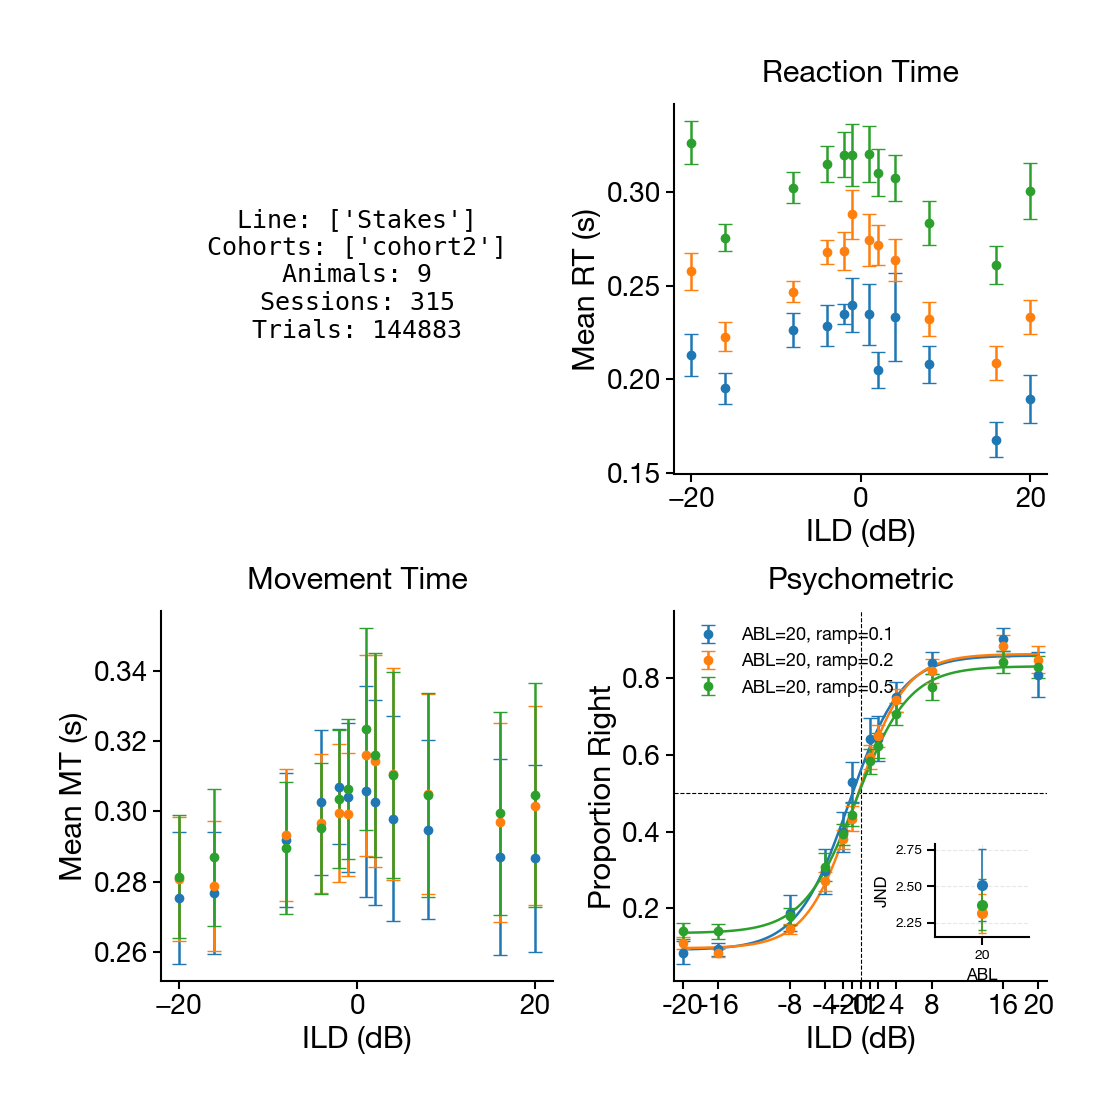

In [5]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)
plt.close("all")

fig_group_daily = daily_plots.plot_stakes_group_summary_with_jnd(
    group_prepared,
    figsize=(10, 10),
)

## 6. Figure 2: Chronometric Function by Trial Outcome


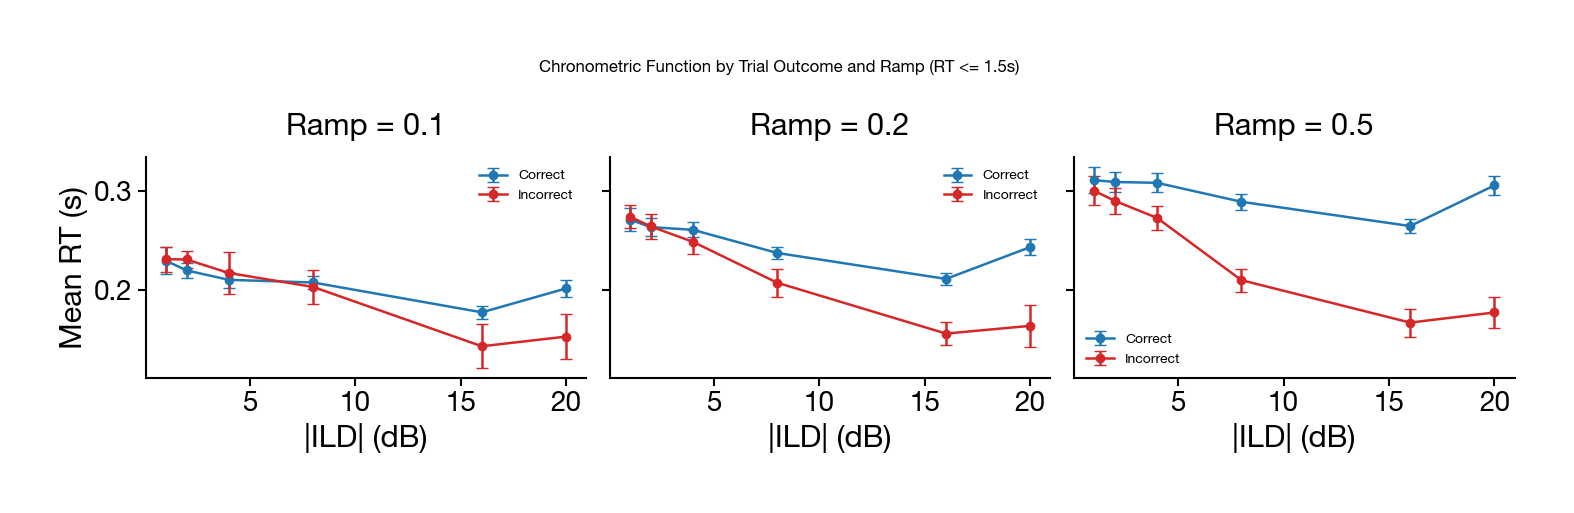

,sound_ramp_time_num,trial_outcome,abs_ILD,mean,sem,n
0,0.1,Correct,1.0,0.229548,0.014077,9
1,0.1,Correct,2.0,0.219575,0.007834,9
2,0.1,Correct,4.0,0.210070,0.007917,9
3,0.1,Correct,8.0,0.207352,0.006674,9
4,0.1,Correct,16.0,0.177155,0.006642,9
5,0.1,Correct,20.0,0.201368,0.008528,9
6,0.1,Incorrect,1.0,0.230977,0.012776,9
7,0.1,Incorrect,2.0,0.230650,0.008569,9
8,0.1,Incorrect,4.0,0.216980,0.021362,9
9,0.1,Incorrect,8.0,0.202859,0.017227,9


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Pipeline.daily_plots import apply_daily_plot_style, style_axes

apply_daily_plot_style()

RT_MAX_SECONDS = 1.5

df_chrono = group_prepared["df"].copy()
df_chrono["abs_ILD"] = pd.to_numeric(df_chrono["ILD"], errors="coerce").abs()
df_chrono["success_num"] = pd.to_numeric(df_chrono["success"], errors="coerce")
df_chrono["timed_rt"] = pd.to_numeric(df_chrono["timed_rt"], errors="coerce")
df_chrono["sound_ramp_time_num"] = pd.to_numeric(df_chrono.get("sound_ramp_time"), errors="coerce")
df_chrono = df_chrono[df_chrono["success_num"].isin([1, -1])].copy()
df_chrono = df_chrono.dropna(subset=["animal", "abs_ILD", "timed_rt", "sound_ramp_time_num"])
df_chrono = df_chrono[df_chrono["timed_rt"].le(RT_MAX_SECONDS)].copy()
df_chrono["trial_outcome"] = np.where(df_chrono["success_num"].eq(1), "Correct", "Incorrect")
ramp_values = sorted(df_chrono["sound_ramp_time_num"].unique())

rt_per_animal = (
    df_chrono.groupby(["animal", "sound_ramp_time_num", "trial_outcome", "abs_ILD"], observed=False)["timed_rt"]
    .mean()
    .reset_index(name="mean_rt")
)

chrono_summary = (
    rt_per_animal.groupby(["sound_ramp_time_num", "trial_outcome", "abs_ILD"], observed=False)["mean_rt"]
    .agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / np.sqrt(x.count()) if x.count() > 1 else np.nan,
        n="count",
    )
    .reset_index()
    .sort_values(["sound_ramp_time_num", "trial_outcome", "abs_ILD"])
)

fig_chrono_outcome, axes = plt.subplots(
    1,
    len(ramp_values),
    figsize=(5 * len(ramp_values), 4),
    sharey=True,
    squeeze=False,
)
axes = axes.ravel()
colors = {"Correct": "C0", "Incorrect": "C3"}

for ax, ramp in zip(axes, ramp_values):
    ramp_sub = chrono_summary[chrono_summary["sound_ramp_time_num"] == ramp]
    for outcome in ["Correct", "Incorrect"]:
        sub = ramp_sub[ramp_sub["trial_outcome"] == outcome]
        if sub.empty:
            continue
        ax.errorbar(
            sub["abs_ILD"],
            sub["mean"],
            yerr=sub["sem"],
            label=outcome,
            color=colors[outcome],
            linestyle="-",
            marker="o",
            capsize=4,
            linewidth=1.8,
        )
    style_axes(
        ax,
        title=f"Ramp = {ramp:g}",
        xlabel="|ILD| (dB)",
        ylabel="Mean RT (s)" if ax is axes[0] else "",
        box_aspect=None,
    )
    ax.legend(frameon=False)

fig_chrono_outcome.suptitle(f"Chronometric Function by Trial Outcome and Ramp (RT <= {RT_MAX_SECONDS:g}s)", y=1.02)
fig_chrono_outcome.tight_layout()
plt.show()

chrono_summary


## 6b. Chronometric Function Sensitivity to Early RT Exclusion


In [5]:
RAMP_VALUES_FOCUS = [0.2, 0.5]
RT_MIN_CUTOFFS_SECONDS = [None] + [ms / 1000 for ms in range(10, 100, 10)]


def summarize_chronometric_by_outcome(df_in, *, rt_min_seconds=None):
    df_plot = df_in.copy()
    if rt_min_seconds is not None:
        df_plot = df_plot[df_plot["timed_rt"].gt(rt_min_seconds)].copy()

    per_animal = (
        df_plot.groupby(["animal", "sound_ramp_time_num", "trial_outcome", "abs_ILD"], observed=False)["timed_rt"]
        .mean()
        .reset_index(name="mean_rt")
    )

    return (
        per_animal.groupby(["sound_ramp_time_num", "trial_outcome", "abs_ILD"], observed=False)["mean_rt"]
        .agg(
            mean="mean",
            sem=lambda x: x.std(ddof=1) / np.sqrt(x.count()) if x.count() > 1 else np.nan,
            n="count",
        )
        .reset_index()
        .sort_values(["sound_ramp_time_num", "trial_outcome", "abs_ILD"])
    )


def count_chronometric_trials(df_in, *, ramp, rt_min_seconds=None):
    df_count = df_in[np.isclose(df_in["sound_ramp_time_num"], ramp)].copy()
    if rt_min_seconds is not None:
        df_count = df_count[df_count["timed_rt"].gt(rt_min_seconds)].copy()
    return len(df_count)


sensitivity_summaries = {
    cutoff: summarize_chronometric_by_outcome(df_chrono, rt_min_seconds=cutoff)
    for cutoff in RT_MIN_CUTOFFS_SECONDS
}

fig_chrono_rt_cutoffs, axes = plt.subplots(
    len(RT_MIN_CUTOFFS_SECONDS),
    len(RAMP_VALUES_FOCUS),
    figsize=(9, 2.0 * len(RT_MIN_CUTOFFS_SECONDS)),
    sharex=True,
    sharey=True,
    squeeze=False,
)

colors = {"Correct": "C0", "Incorrect": "C3"}

for row, cutoff in enumerate(RT_MIN_CUTOFFS_SECONDS):
    summary = sensitivity_summaries[cutoff]
    row_label = "No lower\ncutoff" if cutoff is None else f"RT > {cutoff * 1000:.0f} ms"

    for col, ramp in enumerate(RAMP_VALUES_FOCUS):
        ax = axes[row, col]
        ramp_sub = summary[np.isclose(summary["sound_ramp_time_num"], ramp)]
        n_trials = count_chronometric_trials(df_chrono, ramp=ramp, rt_min_seconds=cutoff)

        for outcome in ["Correct", "Incorrect"]:
            sub = ramp_sub[ramp_sub["trial_outcome"].eq(outcome)]
            if sub.empty:
                continue
            ax.errorbar(
                sub["abs_ILD"],
                sub["mean"],
                yerr=sub["sem"],
                label=outcome,
                color=colors[outcome],
                linestyle="-",
                marker="o",
                capsize=3,
                linewidth=1.4,
                markersize=4,
            )

        ax.text(
            0.96,
            0.08,
            f"n = {n_trials:,}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color="0.25",
        )

        title = f"Ramp = {ramp:g}" if row == 0 else ""
        xlabel = "|ILD| (dB)" if row == len(RT_MIN_CUTOFFS_SECONDS) - 1 else ""
        ylabel = row_label if col == 0 else ""
        style_axes(ax, title=title, xlabel=xlabel, ylabel=ylabel, box_aspect=None)

        if row == 0 and col == len(RAMP_VALUES_FOCUS) - 1:
            ax.legend(frameon=False, loc="best")

fig_chrono_rt_cutoffs.supylabel("Mean RT (s)", x=0.02)
fig_chrono_rt_cutoffs.suptitle(
    f"Chronometric Function by Trial Outcome: early RT exclusions (RT <= {RT_MAX_SECONDS:g}s)",
    y=0.995,
)
fig_chrono_rt_cutoffs.tight_layout(rect=[0.04, 0, 1, 0.985])
plt.show()


NameError: name 'df_chrono' is not defined

## 7. Figure 3: Sound Ramp Comparison

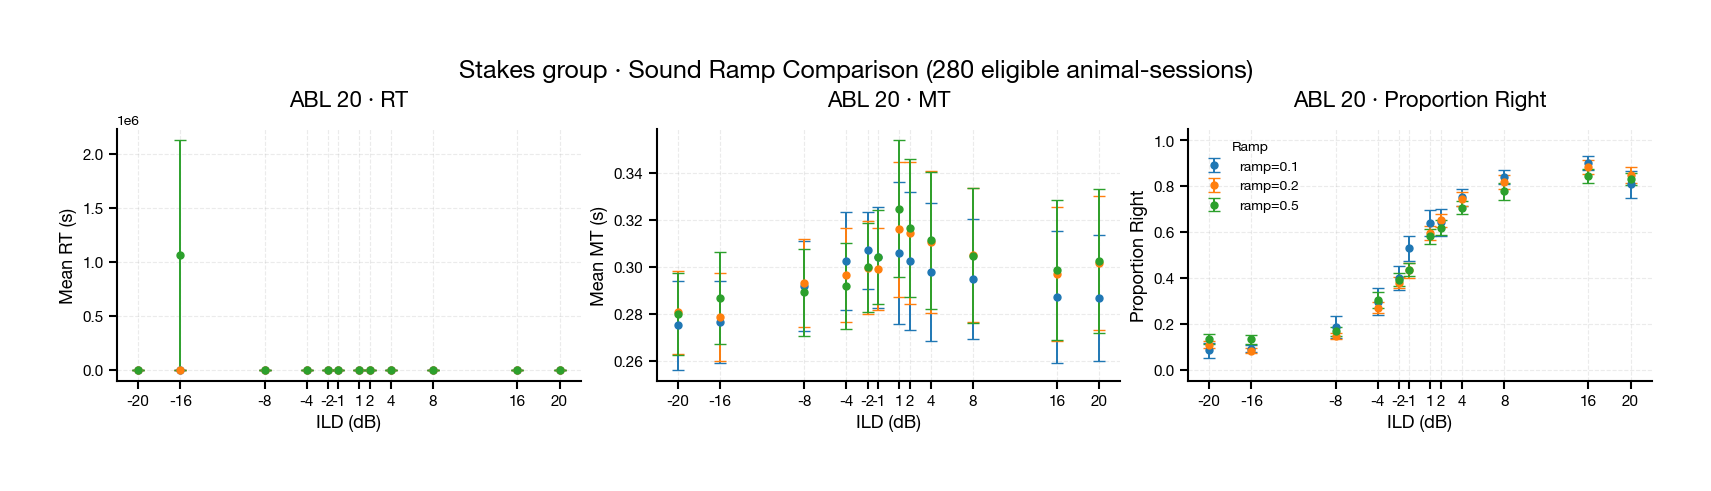

In [7]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)

fig_group_sound_ramp = daily_plots.plot_stakes_group_sound_ramp_comparison(
    group_prepared,
)

## 8. Figure 4: Across Sessions by Sound Ramp

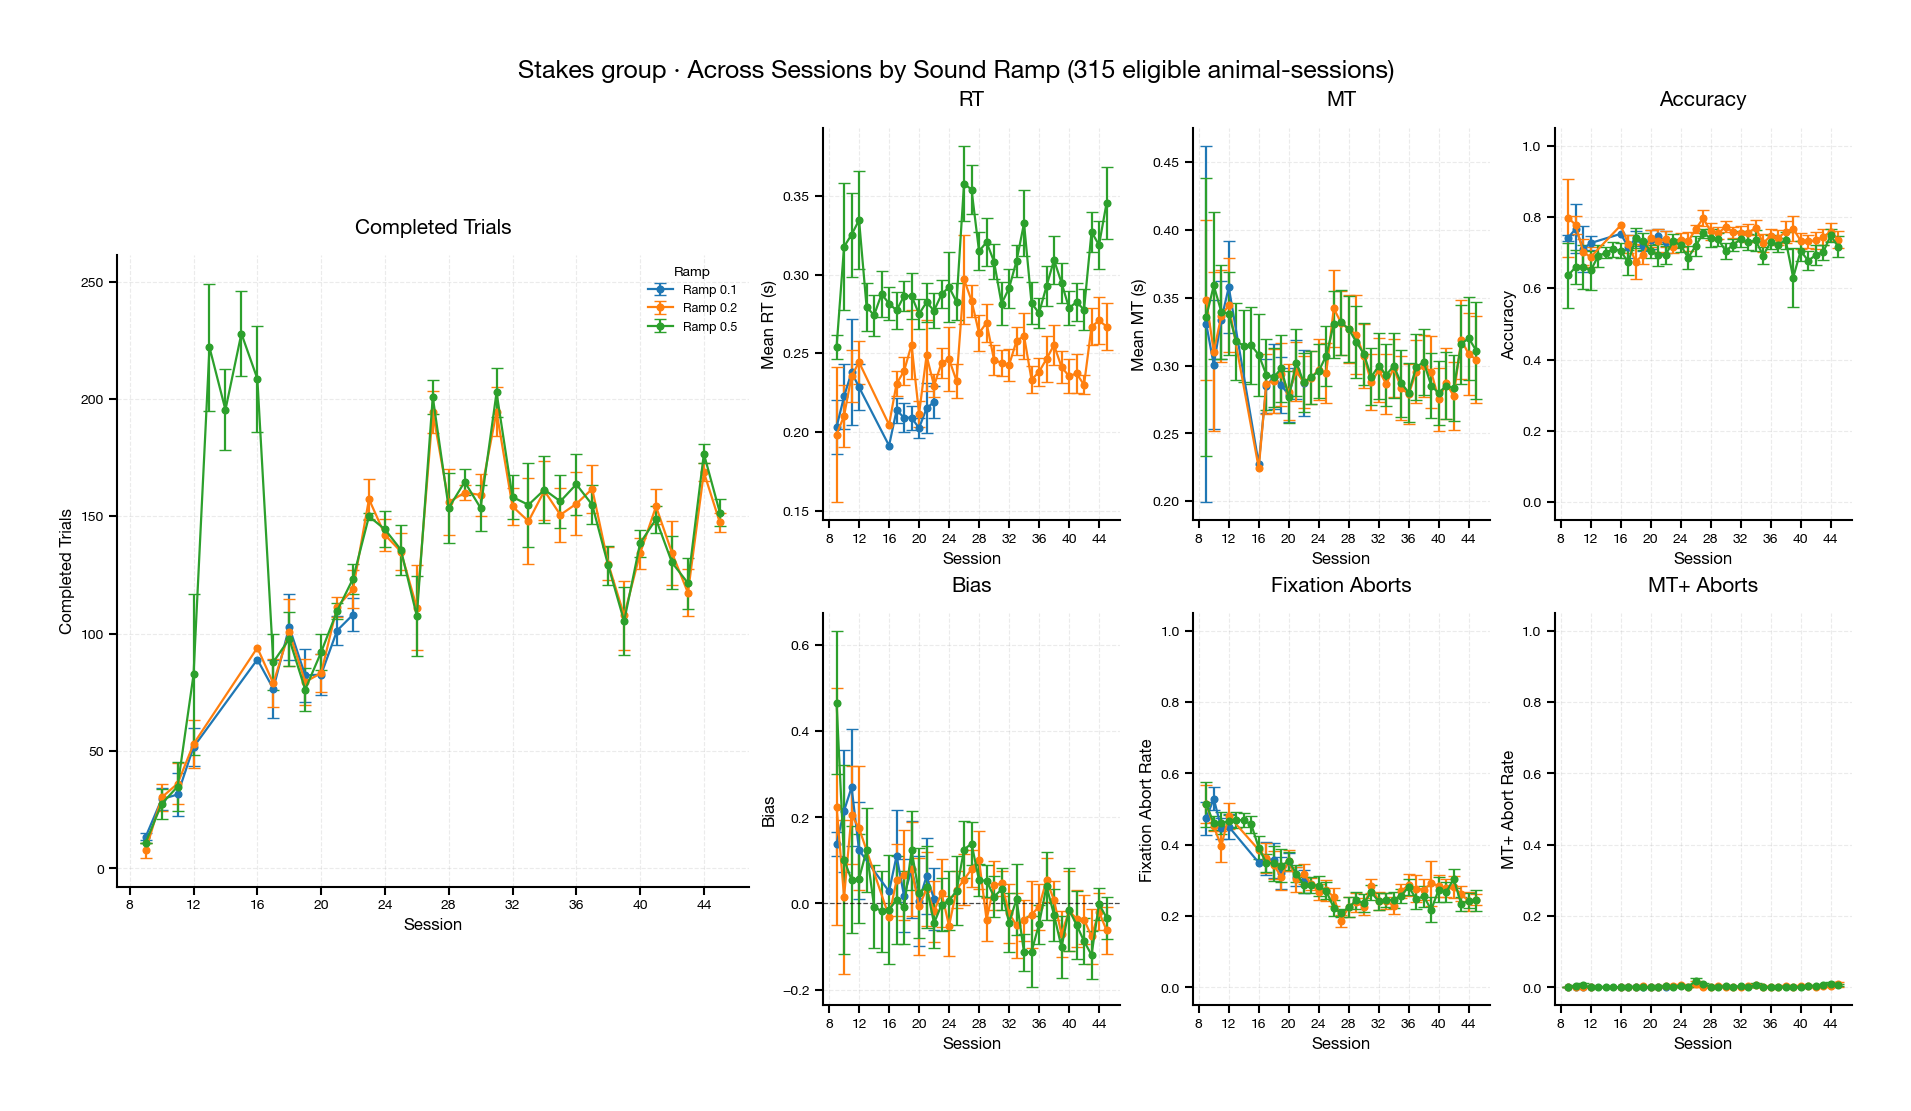

In [8]:
import importlib
import matplotlib.pyplot as plt
import Pipeline.daily_plots as daily_plots

importlib.reload(daily_plots)

fig_group_ramp_sessions = daily_plots.plot_stakes_group_ramp_across_sessions(
    group_prepared,
)